# 기말고사

### 1번 문제

In [1]:
#데이터 처리와 시각화를 위한 라이브러리
import pandas as pd
import matplotlib.pyplot as plt

#머신러닝 도구
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# CSV 파일 불러오기
df = pd.read_csv("cafe_daily_sales.csv")

# 데이터 확인
print(df.head())

         date day_of_week  temperature  foot_traffic  promotion  sales
0  2026-03-02         Mon          5.8         471.0          1  286.9
1  2026-03-03         Tue          2.6         559.0          0  302.7
2  2026-03-04         Wed          7.3         425.0          0  276.9
3  2026-03-05         Thu          8.0         484.0          0  246.2
4  2026-03-06         Fri          1.0         424.0          1  303.3


In [2]:
print("전체 행 수:", len(df))

print("\n열별 결측값 개수")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()

print("\n중복된 행 개수:", duplicate_count)

df = df.drop_duplicates()

print("중복 제거 후 행 수:", len(df))

df["day_of_week"] = df["day_of_week"].str.strip()

print("\nday_of_week 고유값")

print(sorted(df["day_of_week"].unique()))

print("고유값 개수:", df["day_of_week"].nunique())

before_rows = len(df)

df = df.dropna(subset=["sales"])

after_rows = len(df)

print("\nsales 결측값 제거 전 행 수:", before_rows)
print("sales 결측값 제거 후 행 수:", after_rows)
print("제거된 행 수:", before_rows - after_rows)

temp_mean = df["temperature"].mean()

df["temperature"] = df["temperature"].fillna(temp_mean)

print("\ntemperature 결측값 처리 후")
print("temperature 결측값 개수:", df["temperature"].isnull().sum())

# =====================================
# 6. foot_traffic 이상치 제거 (IQR 기준)
# =====================================

Q1 = df["foot_traffic"].quantile(0.25)
Q3 = df["foot_traffic"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_rows = len(df)

df = df[
    (df["foot_traffic"] >= lower_bound) &
    (df["foot_traffic"] <= upper_bound)
]

after_rows = len(df)

print("\nfoot_traffic 이상치 제거")
print("제거 전 행 수:", before_rows)
print("제거 후 행 수:", after_rows)
print("제거된 행 수:", before_rows - after_rows)

# =====================================
# 7. sales_level 열 생성
# =====================================

def classify_sales_level(sales):
    if sales >= 3800000:
        return "높음"
    elif sales >= 3000000:
        return "보통"
    else:
        return "낮음"

df["sales_level"] = df["sales"].apply(classify_sales_level)

print("\nsales_level 분포")
print(df["sales_level"].value_counts())

# 생성 결과 확인
print("\n데이터 확인")
print(df[["sales", "sales_level"]].head())

print("\n최종 데이터 행 수:", len(df))
print("\n최종 데이터 상위 5행")
print(df.head())

전체 행 수: 105

열별 결측값 개수
date            0
day_of_week     0
temperature     5
foot_traffic    0
promotion       0
sales           4
dtype: int64

중복된 행 개수: 3
중복 제거 후 행 수: 102

day_of_week 고유값
['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed']
고유값 개수: 7

sales 결측값 제거 전 행 수: 102
sales 결측값 제거 후 행 수: 98
제거된 행 수: 4

temperature 결측값 처리 후
temperature 결측값 개수: 0

foot_traffic 이상치 제거
제거 전 행 수: 98
제거 후 행 수: 96
제거된 행 수: 2

sales_level 분포
sales_level
낮음    96
Name: count, dtype: int64

데이터 확인
   sales sales_level
0  286.9          낮음
1  302.7          낮음
2  276.9          낮음
3  246.2          낮음
4  303.3          낮음

최종 데이터 행 수: 96

최종 데이터 상위 5행
         date day_of_week  temperature  foot_traffic  promotion  sales  \
0  2026-03-02         Mon          5.8         471.0          1  286.9   
1  2026-03-03         Tue          2.6         559.0          0  302.7   
2  2026-03-04         Wed          7.3         425.0          0  276.9   
3  2026-03-05         Thu          8.0         484.0          0  

##### 1번 문제 9번 조건: 결측값 두가지를 서로 다르게 처리한 이유
> sales는 예측 대상인 목표 변수이므로 결측값 행은 학습에 사용할 수 없기에 제거하였고,  
  temperature는 입력 변수이므로 해당 행의 다른 정보와 매출 데이터는 활용 가능하기에, 평균값으로 결측치를 대체하였습니다.

### 2번 문제

In [3]:
# 요구사항A: 집계분석
weekday_sales_mean = (
    df.groupby("day_of_week")["sales"]
      .mean()
      .sort_values(ascending=False)
)
print("요일별 평균 매출 (내림차순)")
print(weekday_sales_mean)
# =====================================
promotion_sales_mean = (
    df.groupby("promotion")["sales"]
      .mean()
)
print("\n프로모션 진행 여부별 평균 매출")
print(promotion_sales_mean)
# =====================================
sales_level_summary = (
    df.groupby("sales_level")
      .agg(
          days=("sales_level", "count"),
          avg_foot_traffic=("foot_traffic", "mean")
      )
)
# =====================================
print("\nsales_level별 일수 및 평균 유동인구")
print(sales_level_summary)

top5_sales_days = (
    df.sort_values(by="sales", ascending=False)
      [["date", "day_of_week", "promotion", "sales"]]
      .head(5)
)

print("\n매출 상위 5일")
print(top5_sales_days)

요일별 평균 매출 (내림차순)
day_of_week
Sun    438.871429
Sat    408.107143
Fri    335.978571
Thu    325.493333
Tue    319.640000
Wed    317.978571
Mon    296.090000
Name: sales, dtype: float64

프로모션 진행 여부별 평균 매출
promotion
0    333.803333
1    378.411111
Name: sales, dtype: float64

sales_level별 일수 및 평균 유동인구
             days  avg_foot_traffic
sales_level                        
낮음             96        569.979167

매출 상위 5일
          date day_of_week  promotion  sales
86  2026-05-24         Sun          1  555.6
57  2026-04-26         Sun          1  513.5
78  2026-05-16         Sat          1  499.7
65  2026-05-03         Sun          1  497.7
36  2026-04-05         Sun          1  459.0


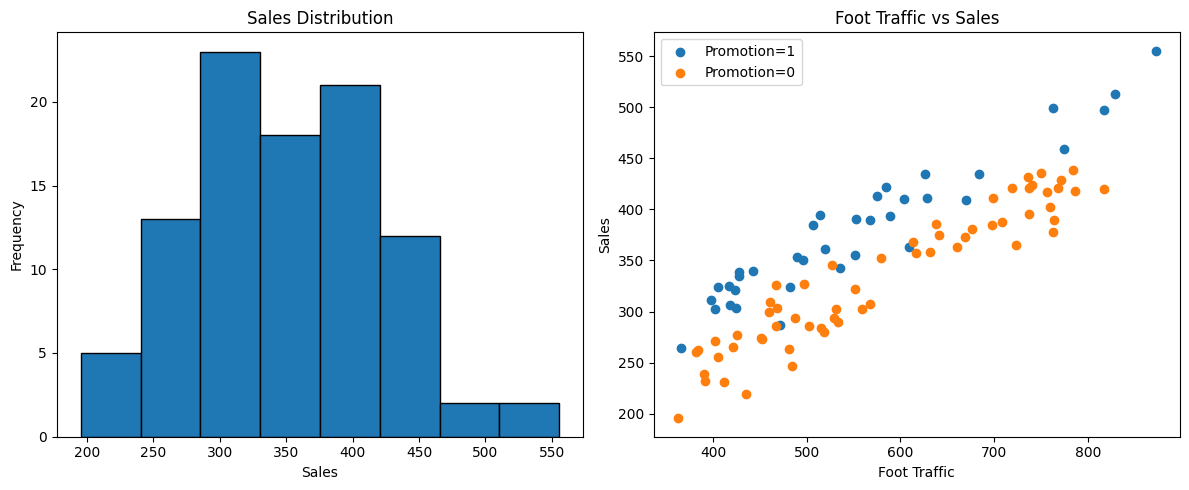

In [4]:
# 요구사항B: 시각화
plt.figure(figsize=(12, 5))
# 왼쪽: sales 히스토그램
# -----------------------------
plt.subplot(1, 2, 1)

plt.hist(
    df["sales"],
    bins=8,
    edgecolor="black"
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
# 오른쪽: foot_traffic - sales 산점도
# promotion 여부에 따라 색상 구분
plt.subplot(1, 2, 2)

for promo in df["promotion"].unique():
    subset = df[df["promotion"] == promo]

    plt.scatter(
        subset["foot_traffic"],
        subset["sales"],
        label=f"Promotion={promo}"
    )

plt.title("Foot Traffic vs Sales")
plt.xlabel("Foot Traffic")
plt.ylabel("Sales")
plt.legend()

# 그래프 간 간격 조정
plt.tight_layout()

plt.show() 

# 요구사항C: 해석
> 1. 요일별 평균 매출을 분석한 결과, 평균 매출이 가장 높은 요일은 일요일이며,
  평균 매출은 438만원으로 나타났다. 반면 평균 매출이 가장 낮은 요일은 월요일로 296만원 수준이어서 요일에 따라 매출 차이가 존재함을 확인할 수 있었다.
> 2. 프로모션 진행일의 평균 매출이 미진행일보다 높게 나타났더라도, 이 차이만으로 프로모션의 효과라고 단정하기는 어렵다. 산점도를 보면 프로모션 진행일 데이터가 대체로 더 높은 유동인구 구간에 많이 분포하고 있으며, 유동인구가 증가할수록 매출도 함께 증가하는 경향이 나타난다. 따라서 프로모션 진행 여부뿐만 아니라 유동인구 규모가 매출에 영향을 주었을 가능성이 있으므로, 평균 매출 차이를 모두 프로모션 효과로 해석할 수는 없다.

#### 3번 문제

In [6]:

# 단순 회귀 모델
X = df[["foot_traffic"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred = simple_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("단순 회귀 모델 성능")

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
# 다중 회귀 모델
df["promotion"] = df["promotion"].replace({
    "Yes": 1,
    "No": 0
})

X = df[["temperature", "foot_traffic", "promotion"]]
y = df["sales"]

# 훈련 데이터 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# 선형회귀 모델 생성 및 학습
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

# 예측
y_pred = multiple_model.predict(X_test)

# 성능 평가
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("다중 회귀 모델 성능")

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

단순 회귀 모델 성능
MAE: 27.515579238805373
RMSE: 33.435564153138195
R²: 0.6454452359173333
다중 회귀 모델 성능
MAE: 14.390192939629296
RMSE: 17.101024156818774
R²: 0.9072507822483163
